### Importing packages

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import PIL.Image as pil
from torchvision import transforms

### Clone git repo

In [2]:
%%cmd
git clone https://github.com/saikatdutta/Stacked_DMSHN_bokeh.git

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>git clone https://github.com/saikatdutta/Stacked_DMSHN_bokeh.git


Cloning into 'Stacked_DMSHN_bokeh'...



C:\Qualcomm\AIStack\models\Background_Blur>

### Apply patch to save onnx 

In [3]:
%%cmd
cd Stacked_DMSHN_bokeh
git apply "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\onnx_export.patch"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>git apply "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\onnx_export.patch"


C://Qualcomm//AIStack//models//Background_Blur//assets//onnx_export.patch:59: new blank line at EOF.
+



C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

### Run  DMSHN_test.py to save onnx

In [4]:
%%cmd
cd Stacked_DMSHN_bokeh
python DMSHN_test.py

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>python DMSHN_test.py


100%|##########| 1/1 [00:35<00:00, 35.18s/it]



C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

### Preprocess

In [22]:
image_path = 'C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\blur_1.jpg'   # change input path

# Load image and preprocess
feed_width = 1536
feed_height = 1024
input_image = pil.open(image_path).convert('RGB')
original_width, original_height = input_image.size

input_image = input_image.resize((feed_width, feed_height), pil.LANCZOS)
input_image = transforms.ToTensor()(input_image).unsqueeze(0)
input_image.detach().cpu().numpy().transpose(0,2,3,1).astype(np.float32).tofile(f"Stacked_DMSHN_bokeh/input.raw")

In [23]:
os.environ['QNN_ROOT']="C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"
os.environ['PYTHONPATH']= "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\lib\\python"
os.environ['PATH']=os.environ['PATH']+"C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\bin\\aarch64-windows-msvc"

### Save raw path to input list

In [24]:
with open("Stacked_DMSHN_bokeh/input_list.txt","w") as file:
    for raw in os.listdir("Stacked_DMSHN_bokeh/"):
        if ".raw" in raw:
            file.write(raw)

##### Copy all files from bin\arm64x-windows-msvc,  lib\arm64x-windows-msvc and lib\hexagon-v73\unsigned to Current directory

In [8]:
import shutil
SDK_dir = "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"       # Specify what's QNN SDK used
SDK_lib_dir = SDK_dir + "\\lib\\arm64x-windows-msvc"
SDK_skel = SDK_dir + "\\lib\\hexagon-v73\\unsigned"

# Copy necessary libraries to a common location
libs = ["QnnCpu.dll","QnnHtp.dll", "QnnSystem.dll", "QnnHtpNetRunExtensions.dll", "QnnHtpPrepare.dll", "QnnHtpV73Stub.dll"]
for lib in libs:
    shutil.copy(SDK_lib_dir + "\\" + lib, "Stacked_DMSHN_bokeh")
skel_libs = ["libqnnhtpv73.cat", "libQnnHtpV73.so", "libQnnHtpV73Skel.so"]
# Copy Skel
for lib in skel_libs:
    shutil.copy(SDK_skel + "\\" + lib, "Stacked_DMSHN_bokeh")

### Convert onnx to .cpp and .bin

In [9]:
%%cmd
cd Stacked_DMSHN_bokeh
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.onnx" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.onnx" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.cpp"


2024-06-14 23:46:26,392 - 235 - INFO - Skipping quantization, no input_list provided
2024-06-14 23:46:26,392 - 235 - INFO - Saving QNN Model...
2024-06-14 23:46:26,471 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.cpp 
2024-06-14 23:46:26,471 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\Background_Blur\assets\float32\dmshn.bin 
2024-06-14 23:46:26,487 - 235 - INFO - Conversion complete!



C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

In [ ]:
'''
[NOT TESTED]
If you want to convert the model to int16 instead of int8, please use the following command in the cell below: 
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" ^
    -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.onnx" ^
    --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp" ^
    --act_bw 16 --weight_bw 16 --bias_bw 8
'''

In [10]:
%%cmd
cd Stacked_DMSHN_bokeh
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp"


2024-06-14 23:47:55,891 - 235 - INFO - Saving QNN Model...
2024-06-14 23:47:55,990 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp 
2024-06-14 23:47:56,000 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\Background_Blur\assets\int8\dmshn.bin 
2024-06-14 23:47:56,012 - 235 - INFO - Conversion complete!


     2.3ms [  INFO ] Inferences will run in sync mode
     3.2ms [  INFO ] Initializing logging in the backend. Callback: [00007FFDC4157810], Log Level: [3]
     3.3ms [  INFO ] No BackendExtensions lib provided;initializing NetRunBackend Interface
     3.5ms [WARNING] Unable to find a device with NetRunDeviceKeyDefault in Library NetRunBackendLibKeyDefault
     3.8ms [  INFO ] Entering QuantizeRuntimeApp flow
    57.5ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::finalize
   450.5ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
 56587.1ms [  INFO ] cleaning up resources for input tensors
 56588.7ms [  INFO ] cleaning up resources for output tensors
 56762.5ms [  INFO ] Freeing graphsInfo

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

In [11]:
%%cmd
cd Stacked_DMSHN_bokeh
mkdir "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.



A subdirectory or file C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs already exists.


C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>mkdir "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs"

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

### Generate model.dll 

In [12]:
%%cmd
cd Stacked_DMSHN_bokeh
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32" -t windows-aarch64 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32" -t windows-aarch64 


2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.cpp
2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\float32\\dmshn.bin
2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32
2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-14 23:48:32,869 -    INFO - qnn-model-lib-generator: Output library name  : dmshn.dll
2024-06-14 23:48:33,185 -    INFO - qnn-model-lib-gen


C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

In [13]:
%%cmd
cd Stacked_DMSHN_bokeh
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\int8" -t  windows-aarch64

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.bin" -o "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\int8" -t  windows-aarch64


2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.cpp
2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\int8\\dmshn.bin
2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\int8
2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-14 23:51:26,724 -    INFO - qnn-model-lib-generator: Output library name  : dmshn.dll
2024-06-14 23:51:26,853 -    INFO - qnn-model-lib-generator: D


C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

### Generate serialized binary

In [14]:
json_str = """{
    "graphs": {
        "vtcm_mb":8,
        "graph_names":[],
        "O":3.0
    },
    "devices": [
        {
            "soc_id": 60,
            "dsp_arch": "v73",
            "cores":[{
                "core_id": 0,
                "perf_profile": "burst",
                "rpc_control_latency":100
            }]
        }
    ]
}"""
f = open(".\\Stacked_DMSHN_bokeh\\htp_backend_extensions.json", "w")
f.write(json_str)
f.close()

In [15]:
%%cmd
cd Stacked_DMSHN_bokeh
qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\int8\ARM64\dmshn.dll"  --backend "QnnHtp.dll" --binary_file dmshn.serialized --config_file "htp_backend_extensions.json"
move  output\dmshn.serialized.bin "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.serialized.bin"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\int8\ARM64\dmshn.dll"  --backend "QnnHtp.dll" --binary_file dmshn.serialized --config_file "htp_backend_extensions.json"
qnn-context-binary-generator pid:21120
Starting stage: Graph Preparation Initializing
Completed stage: Graph Preparation Initializing (195 us)
Starting stage: Graph Transformations and Optimizations
Completed stage: Graph Transformations and Optimizations (1711380 us)
Starting stage: Graph Sequencing for Target
 [##################################################] 100%
Completed stage: Graph Sequencing for Target (1307606 us)
Starting stage: VTCM Allocation
Completed stage: VTCM Allocation (505000 us)
Starting stage: Parallelization Optimization

In [16]:
%%cmd 
cd Stacked_DMSHN_bokeh
rmdir /s  output_cpu
Y
rmdir /s  output_dsp 
Y

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>rmdir /s  output_cpu
output_cpu, Are you sure (Y/N)? Y

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>rmdir /s  output_dsp 


The system cannot find the file specified.
The system cannot find the file specified.


output_dsp, Are you sure (Y/N)? Y

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

### Execution on CPU

In [25]:
%%cmd
cd Stacked_DMSHN_bokeh
qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32\ARM64\dmshn.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\model_libs\\float32\ARM64\dmshn.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:16628

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

### Execution on HTP

In [26]:
%%cmd
cd Stacked_DMSHN_bokeh
qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.serialized.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\Background_Blur\\assets\\dmshn.serialized.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:7612

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>

### PostProcess

In [27]:
import torch.nn.functional as F
from torchvision.utils import save_image
import torch

def postprocess(path):
    
    plt.figure(dpi=100)
    
    #subplot(r,c) provide the no. of rows and columns
    f, axarr = plt.subplots(1,3,figsize=(20, 20)) 
    axarr[0].imshow(imread(image_path))
    
    results = []
    for id,OUTPUT in enumerate(path):
        for target,result in enumerate(os.listdir(OUTPUT)):
            if "log" not in result:
                edge_maps = []
                for raw in ["_376.raw"]:
                    bok_pred = np.fromfile(OUTPUT+result+"/"+raw,dtype="float32").reshape(1,1024,1536,3)
                    bok_pred = bok_pred.transpose(0,3,1,2)
                    bok_pred = torch.from_numpy(bok_pred)
                    bok_pred = F.interpolate(bok_pred,(1024,1536),mode = 'bilinear')
                    save_image(bok_pred,OUTPUT[:-1]+'.png')
                    axarr[id+1].imshow(imread(OUTPUT[:-1]+'.png'))
    
    axarr[0].title.set_text('Input image')
    axarr[1].title.set_text('CPU')
    axarr[2].title.set_text('HTP')



<Figure size 640x480 with 0 Axes>

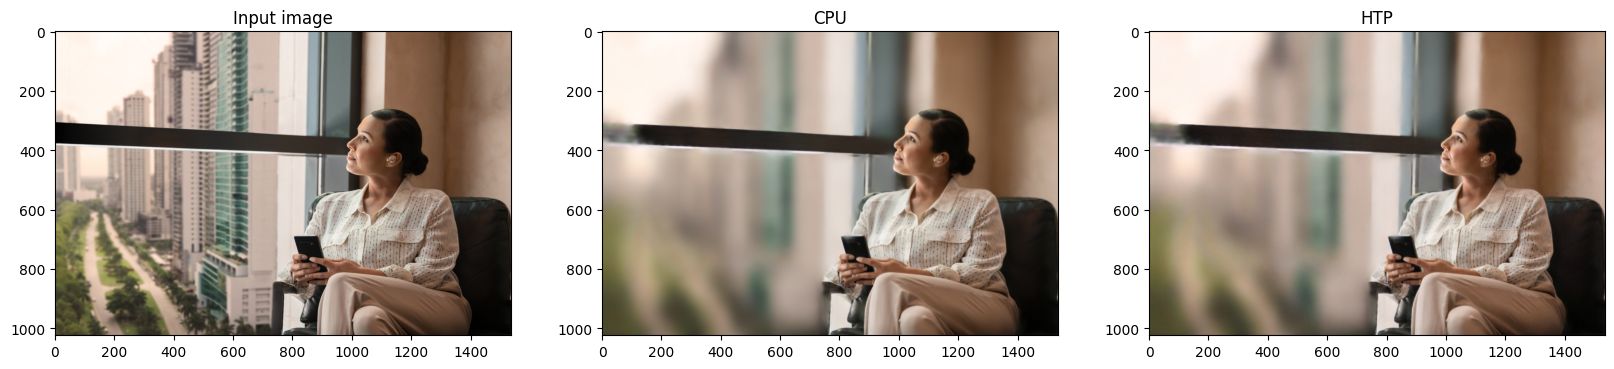

In [28]:
postprocess(["Stacked_DMSHN_bokeh/output_cpu/","Stacked_DMSHN_bokeh/output_dsp/"])

In [29]:
%%cmd
cd Stacked_DMSHN_bokeh
qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log


Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Background_Blur>cd Stacked_DMSHN_bokeh

C:\Qualcomm\AIStack\models\Background_Blur\Stacked_DMSHN_bokeh>qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log
Log File Created: Fri Jun 14 23:53:35 2024
Time Scale: 1e-06
Epoch Timestamp: 1718434415008479 Steady Clock Timestamp: 907421923202
Generated using: 
qnn-profile-viewer v2.21.0.240401120655_85612
qnn-net-run        v2.21.0.240401120655_85612
Backend            v2.21.0.240401120655_85612

Qnn Init/Prepare/Finalize/De-Init/Execute/Lib-Load Statistics:
------------------------------------------------------------
Init Stats:
-----------
    NetRun: 91473 us
    Backend (RPC (load binary) time): 77148 us
    Backend (QNN accelerator (load binary) time): 76068 us
    Backend (Accelerator (load binary) time): 75079 us
    Backend (QNN (load binary) time): 91447 us

Compose Graphs Stats:
--------------
    Ne